![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Análisis de sentimientos y técnicas de NLP

En este taller podrán poner en práctica sus conocimientos sobre las diferentes técnicas para el procesamiento de lenguaje natural. El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción sentimientos de viajeros en Twitter

En este taller se usará el conjunto de datos de sentimientos sobre distintas aerolíneas de EE.UU. provenientes de Twitter. Cada observación contiene si el sentimiento de los tweets es positivo, neutral o negativo teniendo en cuenta distintas variables como aerolínea y las razones de los sentimientos negativos (como "retraso en el vuelo" o "servicio grosero"). El objetivo es predecir el sentimiento asociado a cada tweet. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/crowdflower/twitter-airline-sentiment).

In [13]:
import warnings
warnings.filterwarnings('ignore')

In [14]:
# Importación de librerías
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from nltk.stem.snowball import SnowballStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import nltk
import matplotlib.pyplot as plt
import numpy as np
nltk.download('wordnet')
nltk.download('omw-1.4')

In [15]:
# Lectura de la información de archivo .zip
tweets = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/Tweets.zip', index_col=0)

# Visualización dataset
tweets.head()

,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
tweet_id,,,,,,,,,,,,,,
570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [16]:
# Impresión tamaño del cojunto de datos
tweets.shape

(14640, 14)

### Análisis descriptivo

In [17]:
# Cuenta de tweets por cada sentimiento
tweets['airline_sentiment'].value_counts()

,count
airline_sentiment,
negative,9178
neutral,3099
positive,2363


In [18]:
# Cuenta de tweets por cada aerolínea
tweets['airline'].value_counts()

,count
airline,
United,3822
US Airways,2913
American,2759
Southwest,2420
Delta,2222
Virgin America,504


<Axes: title={'center': 'Sentiminetos por aerolínea'}, xlabel='airline'>

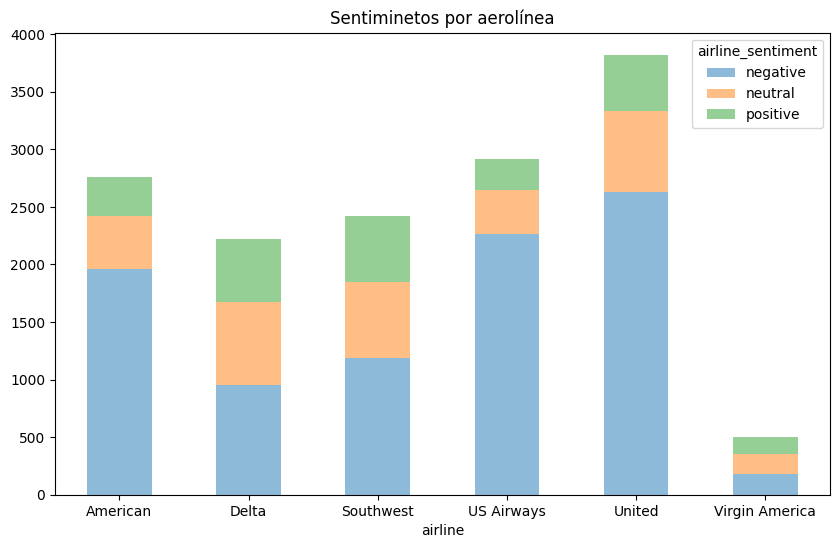

In [19]:
# Plot con cuenta de tweets por cada aerolínea y sentimiento
pd.crosstab(index = tweets["airline"], columns = tweets["airline_sentiment"]).plot(kind='bar',figsize=(10, 6),alpha=0.5,rot=0,stacked=True,title="Sentiminetos por aerolínea")

### Liberias y Variables de interés y predicción

In [21]:
# Separación de variables predictoras (X) y de variable de interés (y)
X = tweets['text']
y = tweets['airline_sentiment'].map({'negative':-1,'neutral':0,'positive':1})

In [22]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Uso de CountVectorizer

En la celda 1 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [24]:
# Celda 1

vectorizer = CountVectorizer()

# ajustar con entrenamimento
X_train_vec = vectorizer.fit_transform(X_train)

# Transformar test
X_test_vec = vectorizer.transform(X_test)

In [25]:
# Crear modelo
rf_model = RandomForestClassifier(random_state=42)

# Entrenar modelo
rf_model.fit(X_train_vec, y_train)

RandomForestClassifier(random_state=42)

In [26]:
# Predecir sobre test
y_pred = rf_model.predict(X_test_vec)

In [27]:
# Calcular accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy del modelo:", accuracy)

Accuracy del modelo: 0.7711092715231788


### Punto 2 - Eliminación de Stopwords

En la celda 2 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer, **eliminen stopwords** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [28]:
# Celda 2
# Vectorizador con eliminación de stopwords
vectorizer_sw = CountVectorizer(stop_words='english')

# Ajustar con entrenamiento
X_train_vec_sw = vectorizer_sw.fit_transform(X_train)

# Transformar test
X_test_vec_sw = vectorizer_sw.transform(X_test)

In [29]:
# Crear modelo
rf_model_sw = RandomForestClassifier(random_state=42)

# Entrenar
rf_model_sw.fit(X_train_vec_sw, y_train)

RandomForestClassifier(random_state=42)

In [30]:
# Predecir
y_pred_sw = rf_model_sw.predict(X_test_vec_sw)

In [31]:
# Accuracy
accuracy_sw = accuracy_score(y_test, y_pred_sw)

print("Accuracy con stopwords eliminadas:", accuracy_sw)

Accuracy con stopwords eliminadas: 0.761796357615894


### Punto 3 - Lematización con verbos

En la celda 3 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer, **lematizen el texto con verbos** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [50]:
# Celda 3
# Inicializar lematizador
lemmatizer = WordNetLemmatizer()

# Obtención e impresión de los lemas de cada palabra de la lista asumiendo que cada palabra es un verbo
def lemmatize_text(text):
    words = text.lower().split()
    # words = text.split()
    lemmatized = [lemmatizer.lemmatize(word, pos='v') for word in words]
    return " ".join(lemmatized)

# Aplicar a train y test
X_train_lem = X_train.apply(lemmatize_text)
X_test_lem = X_test.apply(lemmatize_text)

In [51]:
# Vectorizador
vectorizer_lem = CountVectorizer()

# Ajustar con train
X_train_vec_lem = vectorizer_lem.fit_transform(X_train_lem)

# Transformar test
X_test_vec_lem = vectorizer_lem.transform(X_test_lem)

In [52]:
# Modelo
rf_model_lem = RandomForestClassifier(random_state=42)

# Entrenar
rf_model_lem.fit(X_train_vec_lem, y_train)

RandomForestClassifier(random_state=42)

In [53]:
# Predecir
y_pred_lem = rf_model_lem.predict(X_test_vec_lem)

In [54]:
# Accuracy
accuracy_lem = accuracy_score(y_test, y_pred_lem)

print("Accuracy con lematización:", accuracy_lem)

Accuracy con lematización: 0.7735927152317881


### Punto 4 - Multiples técnicas

En la celda 4 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer, eliminen stopwords, lematizen el texto con verbos** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [56]:
# Celda 4
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.lower().split()
    lemmatized = [lemmatizer.lemmatize(word, pos='v') for word in words]
    return " ".join(lemmatized)

# Aplicar
X_train_lem2 = X_train.apply(lemmatize_text)
X_test_lem2 = X_test.apply(lemmatize_text)

In [57]:
# Vectorizador con stopwords
vectorizer_mix = CountVectorizer(stop_words='english')

# Ajustar con train
X_train_vec_mix = vectorizer_mix.fit_transform(X_train_lem2)

# Transformar test
X_test_vec_mix = vectorizer_mix.transform(X_test_lem2)

In [58]:
rf_model_mix = RandomForestClassifier(random_state=42)

rf_model_mix.fit(X_train_vec_mix, y_train)

RandomForestClassifier(random_state=42)

In [59]:
y_pred_mix = rf_model_mix.predict(X_test_vec_mix)

In [60]:
accuracy_mix = accuracy_score(y_test, y_pred_mix)

print("Accuracy con múltiples técnicas:", accuracy_mix)

Accuracy con múltiples técnicas: 0.7644867549668874


### Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos (random forest) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

## Conclusiones y análisis de resultados



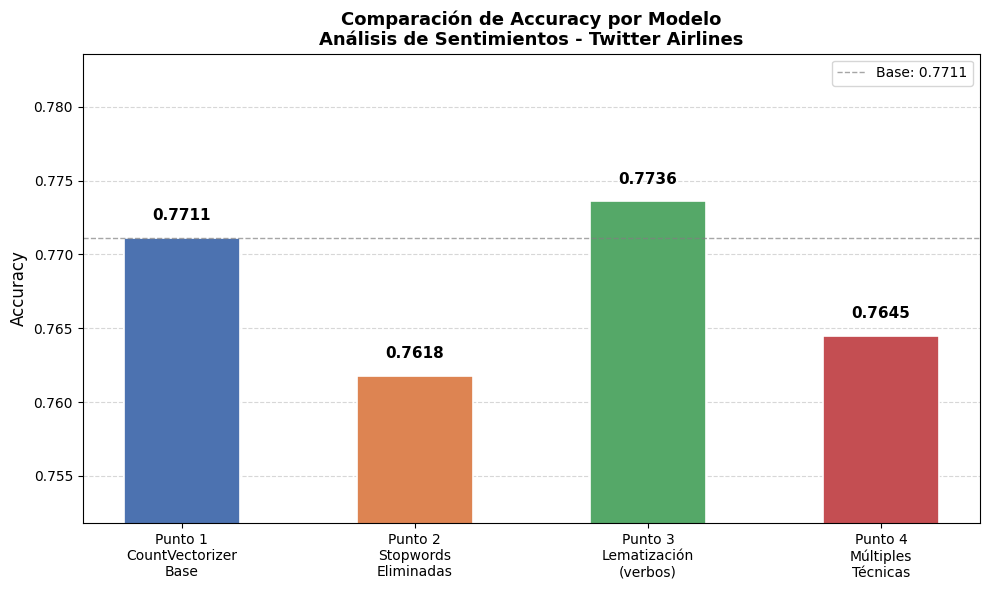

In [61]:
modelos = [
    'Punto 1\nCountVectorizer\nBase',
    'Punto 2\nStopwords\nEliminadas',
    'Punto 3\nLematización\n(verbos)',
    'Punto 4\nMúltiples\nTécnicas'
]

# Leyendo las variables calculadas en cada punto del taller
accuracies = [accuracy, accuracy_sw, accuracy_lem, accuracy_mix]

colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(modelos, accuracies, color=colores, width=0.5, edgecolor='white', linewidth=1.2)

for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f'{acc:.4f}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

ax.axhline(y=accuracies[0], color='gray', linestyle='--', linewidth=1, alpha=0.7, label=f'Base: {accuracies[0]:.4f}')

ax.set_ylim(min(accuracies) - 0.01, max(accuracies) + 0.01)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Comparación de Accuracy por Modelo\nAnálisis de Sentimientos - Twitter Airlines', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('accuracy_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

Los cuatro modelos evaluados presentaron accuracies en un rango estrecho (0.7618 – 0.7736),
lo que indica que la arquitectura base (Random Forest + CountVectorizer) ya captura de forma
adecuada los patrones léxicos del corpus, y que las técnicas de preprocesamiento adicionales
tienen un impacto marginal sobre el desempeño global.

**Modelo con mejor desempeño: Lematización con verbos (Punto 3 – Accuracy: 0.7736)**
La lematización superó al modelo base en 0.0025 puntos. La función de preprocesamiento
aplicó normalización a minúsculas antes de lematizar, lo que unifica tokens que difieren
solo en capitalización. Al combinar esto con la reducción a forma verbal canónica, se logra
una mejor generalización del vocabulario, agrupando variantes morfológicas y de capitalización
bajo un mismo token. Aunque la mejora es modesta, es consistente con la naturaleza del problema:
los tweets de aerolíneas contienen muchas formas verbales cargadas de sentimiento, por lo que
normalizar el tiempo y la persona verbal beneficia la representación.

**Impacto negativo de la eliminación de stopwords (Punto 2 – Accuracy: 0.7618)**
Contrario a la intuición general, eliminar stopwords redujo el desempeño en 0.0093 puntos
respecto al modelo base. Esto se explica porque en análisis de sentimientos el valor semántico
de ciertas stopwords es crítico, ya que las negaciones invierten completamente la polaridad
de una expresión. Al eliminarlas, el modelo pierde información discriminante que el
CountVectorizer base sí aprovecha.

**Combinación de técnicas (Punto 4 – Accuracy: 0.7645)**
El modelo que combinó lematización con normalización a minúsculas y eliminación de stopwords
obtuvo un desempeño intermedio, superior al de stopwords solo pero inferior al de lematización
sola. Esto sugiere que la lematización y el lowercasing aportan valor por sí mismos, pero ese
aporte queda parcialmente neutralizado cuando se combina con la remoción de stopwords, que
elimina tokens con carga semántica relevante.

**Consideraciones sobre la métrica de evaluación**
El dataset presenta un desbalance significativo (negativos: 63%, neutros: 21%, positivos: 16%),
lo que limita la interpretabilidad del accuracy como métrica única. Para un análisis más robusto
sería recomendable incorporar métricas como F1-score macro, precision y recall por clase, o
utilizar una matriz de confusión que permita identificar en qué clases falla cada modelo.